# 04. Data Visualization & Trend Analysis

This notebook analyzes the labeled data from StackOverflow and Job Descriptions to visualize:
1.  **Python Usage**: Distribution of domains (AI, Web, etc.) for Python projects.
2.  **Web Development**: Distribution of languages (JS, Python, etc.) in Web-related categories.
3.  **Trends**: Programming language popularity over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as pd_plt
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# --- LOAD DATA ---
file_so = 'data/outputs/dataset_STACKOVERFLOW_gpt.csv'
file_job = 'data/outputs/dataset_job_gpt.csv'

try:
    df_so = pd.read_csv(file_so)
    df_so['source'] = 'stackoverflow'
    print(f"Loaded StackOverflow data: {df_so.shape}")
except FileNotFoundError:
    print(f"Warning: {file_so} not found.")
    df_so = pd.DataFrame()

try:
    df_job = pd.read_csv(file_job)
    df_job['source'] = 'job'
    print(f"Loaded Job data: {df_job.shape}")
except FileNotFoundError:
    print(f"Warning: {file_job} not found.")
    df_job = pd.DataFrame()

# Combine datasets
df = pd.concat([df_so, df_job], ignore_index=True)
print(f"Total data: {df.shape}")

df.head()

Loaded StackOverflow data: (4320, 6)
Loaded Job data: (2000, 6)
Total data: (6320, 7)


,source_type,raw_text,language,event_date,label_gpt,source,label_gemini
0,stackoverflow,how to cancel a “range over func” iteration ea...,go,2025,web backend,stackoverflow,NaN
1,stackoverflow,ioptionssnapshot<t>.get(string? name) returns ...,c#,2025,developer tools,stackoverflow,NaN
2,stackoverflow,"why am i getting an ""error: time zone ""gmt-070...",typescript,2025,data_ai,stackoverflow,NaN
3,stackoverflow,how to make temp 2fa qr code in perl based web...,perl,2025,web backend,stackoverflow,NaN
4,stackoverflow,how do i dynamically adjust the height of my `...,dart,2024,web frontend,stackoverflow,NaN


In [3]:
# --- PREPROCESSING ---

# 1. Handle Multi-value Languages
# Languages are often comma-separated strings like "python, javascript"

def clean_language(lang_str):
    if pd.isna(lang_str):
        return []
    return [x.strip().lower() for x in str(lang_str).split(',')]

# Create an exploded dataframe for Language analysis
df_lang = df.copy()
df_lang['language_list'] = df_lang['language'].apply(clean_language)
df_exploded = df_lang.explode('language_list')
df_exploded.rename(columns={'language_list': 'clean_language'}, inplace=True)

# normalize clean_language
df_exploded = df_exploded[df_exploded['clean_language'] != '']

# 2. Ensure Date is numeric/datetime
df_exploded['event_date'] = pd.to_numeric(df_exploded['event_date'], errors='coerce')
df_exploded = df_exploded.dropna(subset=['event_date'])
df_exploded['event_date'] = df_exploded['event_date'].astype(int)

print("Top 10 Languages found:")
print(df_exploded['clean_language'].value_counts().head(10))

Top 10 Languages found:
clean_language
python        1371
java          1059
javascript     935
c++            687
c#             577
c              451
go             435
typescript     428
r              426
kotlin         418
Name: count, dtype: int64


## 1. Python Analysis: AI vs Web vs Others
Filter mainly for 'python' and see the distribution of `label_gpt`.

/tmp/ipykernel_42962/2684128689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, palette="viridis")


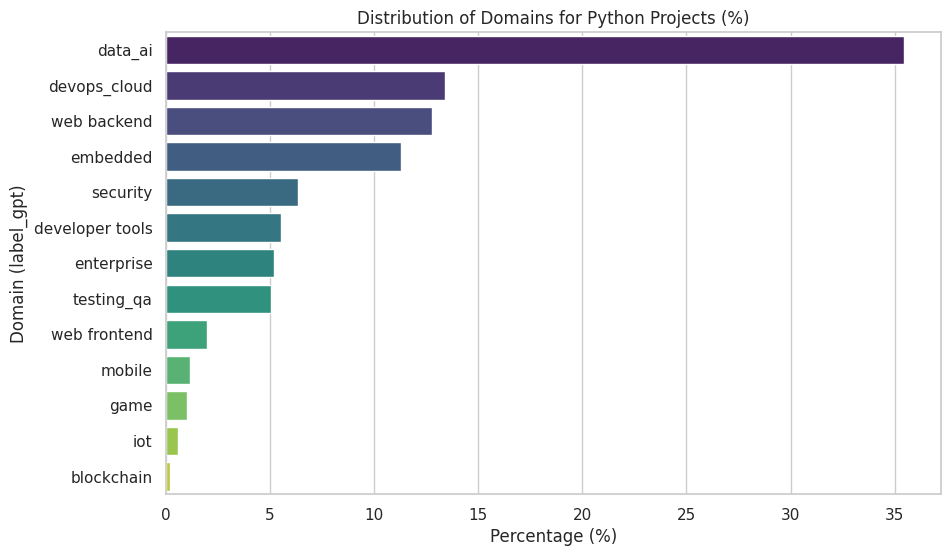

label_gpt
data_ai            35.448578
devops_cloud       13.420861
web backend        12.764406
embedded           11.305616
security            6.345733
developer tools     5.543399
enterprise          5.178702
testing_qa          5.032823
web frontend        1.969365
mobile              1.167031
game                1.021152
iot                 0.583516
blockchain          0.218818
Name: proportion, dtype: float64


In [4]:
# Filter for Python
python_df = df_exploded[df_exploded['clean_language'] == 'python']

# Calculate percentages of domains
domain_counts = python_df['label_gpt'].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.values, y=domain_counts.index, palette="viridis")
plt.title('Distribution of Domains for Python Projects (%)')
plt.xlabel('Percentage (%)')
plt.ylabel('Domain (label_gpt)')
plt.show()

# Print values
print(domain_counts)

## 2. Web Analysis: JS vs Python vs Others
Filter for `label_gpt` containing 'web' and see the distribution of languages.

/tmp/ipykernel_42962/2114199694.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=web_lang_counts.values, y=web_lang_counts.index, palette="magma")


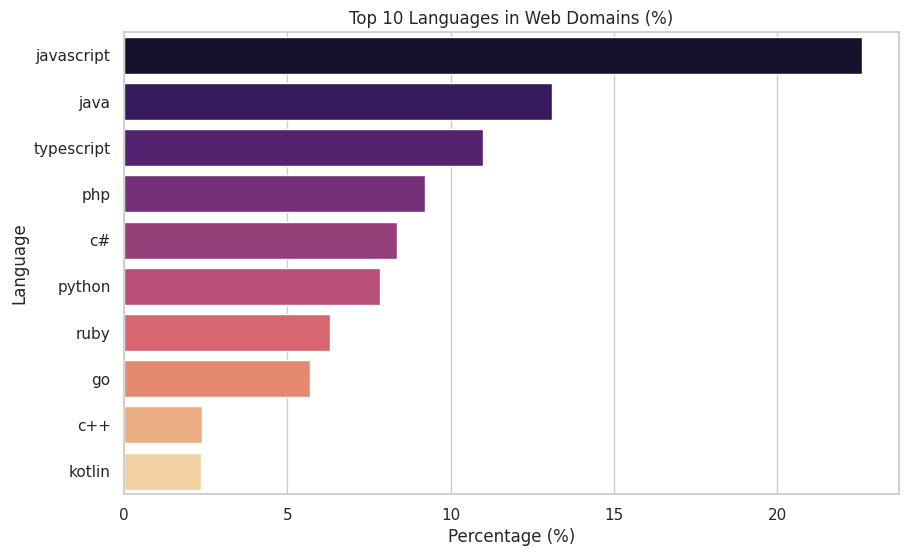

clean_language
javascript    22.588144
java          13.095699
typescript    11.003487
php            9.221232
c#             8.368849
python         7.826424
ruby           6.315382
go             5.695467
c++            2.402170
kotlin         2.363425
Name: proportion, dtype: float64


In [5]:
# Filter for Web domains (Web Frontend, Web Backend, etc.)
web_df = df_exploded[df_exploded['label_gpt'].str.contains('web', case=False, na=False)]

# Calculate percentages of languages in Web
web_lang_counts = web_df['clean_language'].value_counts(normalize=True).head(10) * 100

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=web_lang_counts.values, y=web_lang_counts.index, palette="magma")
plt.title('Top 10 Languages in Web Domains (%)')
plt.xlabel('Percentage (%)')
plt.ylabel('Language')
plt.show()

# Print values
print(web_lang_counts)

## 3. Trend Analysis
Show the popularity of top languages over time (years).

Years available: [np.int64(2023), np.int64(2024), np.int64(2025)]


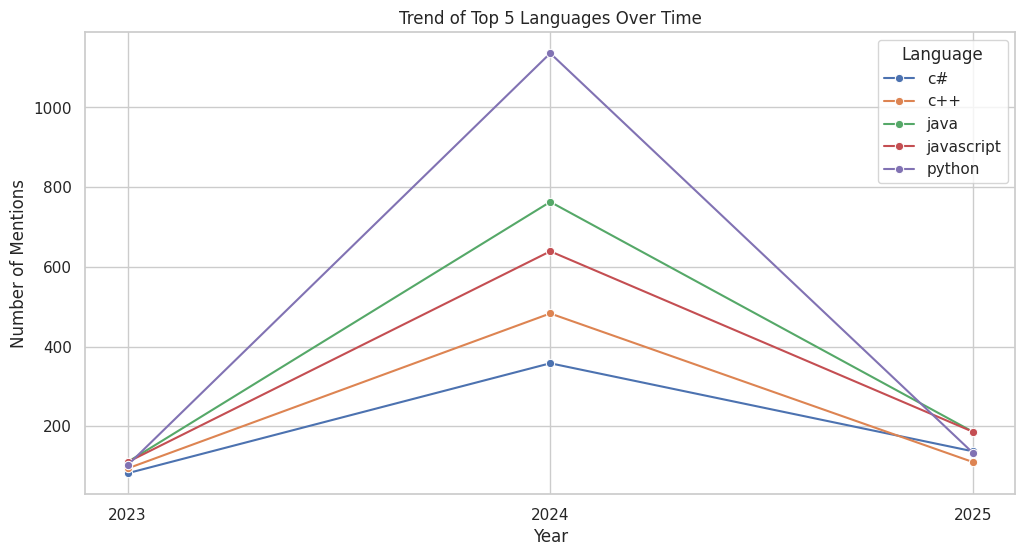

In [6]:
# Ensure we have multiple years
print(f"Years available: {sorted(df_exploded['event_date'].unique())}")

# Get top 5 languages to avoid clutter
top_langs = df_exploded['clean_language'].value_counts().head(5).index.tolist()

# Group by Year and Language
trend_df = df_exploded[df_exploded['clean_language'].isin(top_langs)]
trend_counts = trend_df.groupby(['event_date', 'clean_language']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_counts, x='event_date', y='count', hue='clean_language', marker='o')
plt.title('Trend of Top 5 Languages Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Mentions')
plt.xticks(sorted(df_exploded['event_date'].unique())) # Ensure integer years on x-axis
plt.legend(title='Language')
plt.show()